# Opinion Mining v3: Feature Extraction — Base vs LoRA Fine-Tuned

This notebook upgrades from simple binary sentiment to **full feature extraction**:
- `sentiment` — positive / negative
- `emotions` — e.g. joy, anger, disappointment, excitement
- `aspects` — topics mentioned (acting, plot, visuals, music, pacing...)
- `intensity` — strong / moderate / weak

The richer output makes the base model clearly struggle, so the gap after LoRA fine-tuning is much more visible.

**Changes from v2:**
- 8,000 train / 800 test samples (up from 5,000 / 500)
- LoRA rank r=32, also targets MLP layers
- Multi-field structured output instead of one word
- Separate scoring for each extracted field

## 1. Setup

In [1]:
!pip install -q -U transformers datasets bitsandbytes peft trl accelerate scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 106.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 112.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 112.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 103.3 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the pack

## 2. Dependencies

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import json
import re
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

PyTorch  : 2.10.0+cu128
CUDA     : True


## 3. Dataset Preparation with Feature Labels

IMDB only provides sentiment labels. We derive the other fields automatically from the text so training data is rich and consistent:
- **emotions** — keyword-matched from the review text
- **aspects** — topic keywords detected in the review
- **intensity** — based on presence of strong words and review length

This keeps us self-contained without needing a separate annotated dataset.

In [3]:
dataset = load_dataset("imdb")

train_dataset_raw = dataset['train'].shuffle(seed=42).select(range(8000))
test_dataset_raw  = dataset['test'].shuffle(seed=42).select(range(800))

# ── Feature derivation helpers ────────────────────────────────────────────────

EMOTION_KEYWORDS = {
    "joy"          : ["enjoy", "love", "delight", "wonderful", "fantastic", "fun", "happy", "laugh", "charming", "masterpiece"],
    "anger"        : ["hate", "awful", "terrible", "rage", "furious", "disgusting", "outrage", "annoying", "frustrat"],
    "sadness"      : ["sad", "cry", "tears", "heartbreak", "tragic", "depressing", "grief", "sorrow", "melanchol"],
    "excitement"   : ["excit", "thrilling", "amazing", "incredible", "stunning", "breathtaking", "electrif", "wow"],
    "disappointment": ["disappoint", "boring", "dull", "waste", "expected more", "let down", "poor", "mediocre", "lackluster"],
    "fear"         : ["scary", "terrify", "horror", "nightmare", "disturb", "creep", "tense", "dread"],
    "surprise"     : ["surpris", "unexpected", "twist", "shock", "didn't expect", "caught off guard"],
}

ASPECT_KEYWORDS = {
    "acting"   : ["act", "perform", "cast", "actor", "actress", "character", "role", "portray"],
    "plot"     : ["plot", "story", "script", "storyline", "narrative", "writing", "screenplay", "ending"],
    "visuals"  : ["visual", "cinemat", "cgi", "special effect", "beautifully shot", "look", "color", "scene"],
    "direction": ["direct", "director", "pacing", "edit", "cut", "tone"],
    "music"    : ["music", "score", "soundtrack", "song", "sound"],
    "humor"    : ["funny", "humor", "comedy", "laugh", "hilarious", "wit", "joke"],
}

STRONG_WORDS = [
    "masterpiece", "terrible", "brilliant", "awful", "incredible",
    "horrible", "amazing", "worst", "best", "outstanding", "garbage",
    "perfect", "disaster", "stunning", "dreadful"
]

def derive_features(text, label):
    text_lower = text.lower()

    # Sentiment
    sentiment = "positive" if label == 1 else "negative"

    # Emotions — top 2 matches
    emotion_scores = {}
    for emotion, keywords in EMOTION_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text_lower)
        if score > 0:
            emotion_scores[emotion] = score
    emotions = sorted(emotion_scores, key=emotion_scores.get, reverse=True)[:2]
    if not emotions:
        emotions = ["joy"] if label == 1 else ["disappointment"]

    # Aspects — all matches
    aspects = []
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            aspects.append(aspect)
    if not aspects:
        aspects = ["plot"]  # fallback

    # Intensity
    strong_count = sum(1 for w in STRONG_WORDS if w in text_lower)
    word_count   = len(text.split())
    if strong_count >= 2 or word_count > 200:
        intensity = "strong"
    elif strong_count == 1 or word_count > 80:
        intensity = "moderate"
    else:
        intensity = "weak"

    return sentiment, emotions, aspects, intensity


def format_instruction(sample):
    sentiment, emotions, aspects, intensity = derive_features(sample["text"], sample["label"])

    # Build structured output
    output = (
        f"sentiment: {sentiment} | "
        f"emotions: {', '.join(emotions)} | "
        f"aspects: {', '.join(aspects)} | "
        f"intensity: {intensity}"
    )

    prompt = f"""### Instruction:
Analyze the following review and extract:
1. sentiment (positive/negative)
2. emotions expressed (e.g. joy, anger, sadness, excitement, disappointment, fear, surprise)
3. aspects mentioned (e.g. acting, plot, visuals, direction, music, humor)
4. intensity (strong/moderate/weak)

Output format: sentiment: <s> | emotions: <e1>, <e2> | aspects: <a1>, <a2> | intensity: <i>

### Review:
{sample['text'][:600]}

### Response:
{output}"""

    return {"text": prompt, "sentiment": sentiment, "emotions": str(emotions),
            "aspects": str(aspects), "intensity": intensity}


train_dataset = train_dataset_raw.map(format_instruction)
test_dataset  = test_dataset_raw.map(format_instruction)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print("\nExample output:")
print(train_dataset[0]['text'])

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Train: 8000 | Test: 800

Example output:
### Instruction:
Analyze the following review and extract:
1. sentiment (positive/negative)
2. emotions expressed (e.g. joy, anger, sadness, excitement, disappointment, fear, surprise)
3. aspects mentioned (e.g. acting, plot, visuals, direction, music, humor)
4. intensity (strong/moderate/weak)

Output format: sentiment: <s> | emotions: <e1>, <e2> | aspects: <a1>, <a2> | intensity: <i>

### Review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer Americ

## 4. Load Base Model

In [4]:
model_id = "Qwen/Qwen2.5-0.5B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"":0},
    trust_remote_code=True,
    dtype=torch.float16
)
base_model.config.use_cache = False

print("Base model loaded.")
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()):,}")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Base model loaded.
Parameters: 315,119,488


## 5. Evaluation Helper

We parse the structured output and score each field separately:
- **Sentiment accuracy** — did it get positive/negative right?
- **Emotion hit rate** — did at least one predicted emotion match a true emotion?
- **Aspect hit rate** — did at least one predicted aspect match a true aspect?
- **Intensity accuracy** — did it get strong/moderate/weak right?
- **Format compliance** — did it even produce parseable output?

In [5]:
def parse_output(text):
    """Parse structured model output into a dict."""
    result = {"sentiment": None, "emotions": [], "aspects": [], "intensity": None, "valid": False}
    try:
        # Extract after ### Response:
        if "### Response:" in text:
            text = text.split("### Response:")[-1].strip()

        # sentiment
        sm = re.search(r'sentiment:\s*(positive|negative)', text, re.I)
        if sm:
            result["sentiment"] = sm.group(1).lower()

        # emotions
        em = re.search(r'emotions?:\s*([^|\n]+)', text, re.I)
        if em:
            result["emotions"] = [e.strip().lower() for e in em.group(1).split(',') if e.strip()]

        # aspects
        am = re.search(r'aspects?:\s*([^|\n]+)', text, re.I)
        if am:
            result["aspects"] = [a.strip().lower() for a in am.group(1).split(',') if a.strip()]

        # intensity
        im = re.search(r'intensity:\s*(strong|moderate|weak)', text, re.I)
        if im:
            result["intensity"] = im.group(1).lower()

        result["valid"] = result["sentiment"] is not None
    except Exception:
        pass
    return result


def evaluate_model(model, tokenizer, dataset, num_samples=150, label="Model"):
    model.eval()
    results = []

    eval_data = dataset.select(range(min(num_samples, len(dataset))))

    for i, item in enumerate(eval_data):
        if i > 0 and i % 30 == 0:
            print(f"  [{label}] {i}/{len(eval_data)}")

        # Build inference prompt (no response)
        review_text = item['text'][:600]
        prompt = f"""### Instruction:
Analyze the following review and extract:
1. sentiment (positive/negative)
2. emotions expressed (e.g. joy, anger, sadness, excitement, disappointment, fear, surprise)
3. aspects mentioned (e.g. acting, plot, visuals, direction, music, humor)
4. intensity (strong/moderate/weak)

Output format: sentiment: <s> | emotions: <e1>, <e2> | aspects: <a1>, <a2> | intensity: <i>

### Review:
{review_text}

### Response:
"""
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=600).to("cuda")

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=40,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        full_text  = tokenizer.decode(out[0], skip_special_tokens=True)
        parsed     = parse_output(full_text)

        # Ground truth
        true_sentiment = item['sentiment']
        true_emotions  = eval(item['emotions'])   # stored as string repr of list
        true_aspects   = eval(item['aspects'])
        true_intensity = item['intensity']

        results.append({
            "true_sentiment" : true_sentiment,
            "pred_sentiment" : parsed["sentiment"],
            "true_emotions"  : true_emotions,
            "pred_emotions"  : parsed["emotions"],
            "true_aspects"   : true_aspects,
            "pred_aspects"   : parsed["aspects"],
            "true_intensity" : true_intensity,
            "pred_intensity" : parsed["intensity"],
            "valid"          : parsed["valid"],
        })

    return results


def score_results(results, label=""):
    n = len(results)
    valid      = sum(r["valid"] for r in results)
    sent_acc   = sum(r["pred_sentiment"] == r["true_sentiment"] for r in results if r["valid"]) / n * 100
    emot_hit   = sum(bool(set(r["pred_emotions"]) & set(r["true_emotions"])) for r in results if r["valid"]) / n * 100
    asp_hit    = sum(bool(set(r["pred_aspects"]) & set(r["true_aspects"])) for r in results if r["valid"]) / n * 100
    intens_acc = sum(r["pred_intensity"] == r["true_intensity"] for r in results if r["valid"]) / n * 100
    fmt        = valid / n * 100

    print(f"\n{'='*52}")
    print(f" {label}")
    print(f"{'='*52}")
    print(f"  Format compliance : {fmt:5.1f}%  ({valid}/{n} parseable)")
    print(f"  Sentiment accuracy: {sent_acc:5.1f}%")
    print(f"  Emotion hit rate  : {emot_hit:5.1f}%")
    print(f"  Aspect hit rate   : {asp_hit:5.1f}%")
    print(f"  Intensity accuracy: {intens_acc:5.1f}%")
    print(f"{'='*52}")

    return {"fmt": fmt, "sentiment": sent_acc, "emotion": emot_hit,
            "aspect": asp_hit, "intensity": intens_acc}

print("Evaluation helper ready.")

Evaluation helper ready.


## 6. Evaluate Base Model (Before Fine-Tuning)

The base model has never seen this structured extraction format. Expect low format compliance and poor field scores — this is the gap we'll close with LoRA.

In [6]:
print("Evaluating BASE model...")
base_results = evaluate_model(base_model, tokenizer, test_dataset, num_samples=150, label="Base")
base_scores  = score_results(base_results, label="BASE MODEL (no fine-tuning)")

Evaluating BASE model...
  [Base] 30/150
  [Base] 60/150
  [Base] 90/150
  [Base] 120/150

 BASE MODEL (no fine-tuning)
  Format compliance :  97.3%  (146/150 parseable)
  Sentiment accuracy:  70.7%
  Emotion hit rate  :  69.3%
  Aspect hit rate   :  91.3%
  Intensity accuracy:  43.3%


## 7. Apply LoRA — Stronger Config

Key upgrades vs v2:
- **r=32** (was 16) — more adapter capacity
- **Also targets MLP layers** (`gate_proj`, `up_proj`, `down_proj`) — LoRA now covers both attention and feed-forward, giving the model more surface area to learn the new output format

In [7]:
base_model = prepare_model_for_kbit_training(base_model)

peft_config = LoraConfig(
    r=32,                    # was 16
    lora_alpha=64,           # keep alpha = 2 * r
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",   # attention
        "gate_proj", "up_proj", "down_proj"        # MLP  ← new
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()

trainable params: 17,596,416 || all params: 511,629,184 || trainable%: 3.4393


In [8]:
sft_config = SFTConfig(
    output_dir="./lora_checkpoints_v3",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    save_steps=300,
    logging_steps=100,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=False,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    report_to="none",
    dataset_text_field="text",
    max_length=700,           # longer for structured output
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    args=sft_config,
)

print("Starting LoRA fine-tuning (v3)...")
print("8,000 samples x 3 epochs — expect ~45-55 min on T4")
trainer.train()

trainer.model.save_pretrained("lora_opinion_mining_v3")
tokenizer.save_pretrained("lora_opinion_mining_v3")
print("\nModel saved!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting LoRA fine-tuning (v3)...
8,000 samples x 3 epochs — expect ~45-55 min on T4


Step,Training Loss
100,1.816279
200,1.708370
300,1.697946
400,1.674924
500,1.676625
600,1.549888
700,1.530102
800,1.548224
900,1.538914
1000,1.535402



Model saved!


## 8. Evaluate Fine-Tuned Model

In [9]:
print("Evaluating FINE-TUNED model...")
ft_results = evaluate_model(model, tokenizer, test_dataset, num_samples=150, label="LoRA")
ft_scores  = score_results(ft_results, label="FINE-TUNED MODEL (LoRA r=32, 3 epochs, 8k samples)")

Evaluating FINE-TUNED model...
  [LoRA] 30/150
  [LoRA] 60/150
  [LoRA] 90/150
  [LoRA] 120/150

 FINE-TUNED MODEL (LoRA r=32, 3 epochs, 8k samples)
  Format compliance : 100.0%  (150/150 parseable)
  Sentiment accuracy:  78.7%
  Emotion hit rate  :  70.7%
  Aspect hit rate   :  99.3%
  Intensity accuracy:  49.3%


## 9. Side-by-Side Comparison

In [10]:
# ── 9a. Detailed classification report for sentiment ─────────────────────────
base_valid_r = [r for r in base_results if r["valid"]]
ft_valid_r   = [r for r in ft_results   if r["valid"]]

print("SENTIMENT — Base model:")
if base_valid_r:
    print(classification_report(
        [r["true_sentiment"] for r in base_valid_r],
        [r["pred_sentiment"] for r in base_valid_r]
    ))

print("SENTIMENT — Fine-tuned model:")
if ft_valid_r:
    print(classification_report(
        [r["true_sentiment"] for r in ft_valid_r],
        [r["pred_sentiment"] for r in ft_valid_r]
    ))

SENTIMENT — Base model:
              precision    recall  f1-score   support

    negative       0.79      0.65      0.71        77
    positive       0.67      0.81      0.74        69

    accuracy                           0.73       146
   macro avg       0.73      0.73      0.73       146
weighted avg       0.74      0.73      0.72       146

SENTIMENT — Fine-tuned model:
              precision    recall  f1-score   support

    negative       0.83      0.75      0.79        79
    positive       0.75      0.83      0.79        71

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150



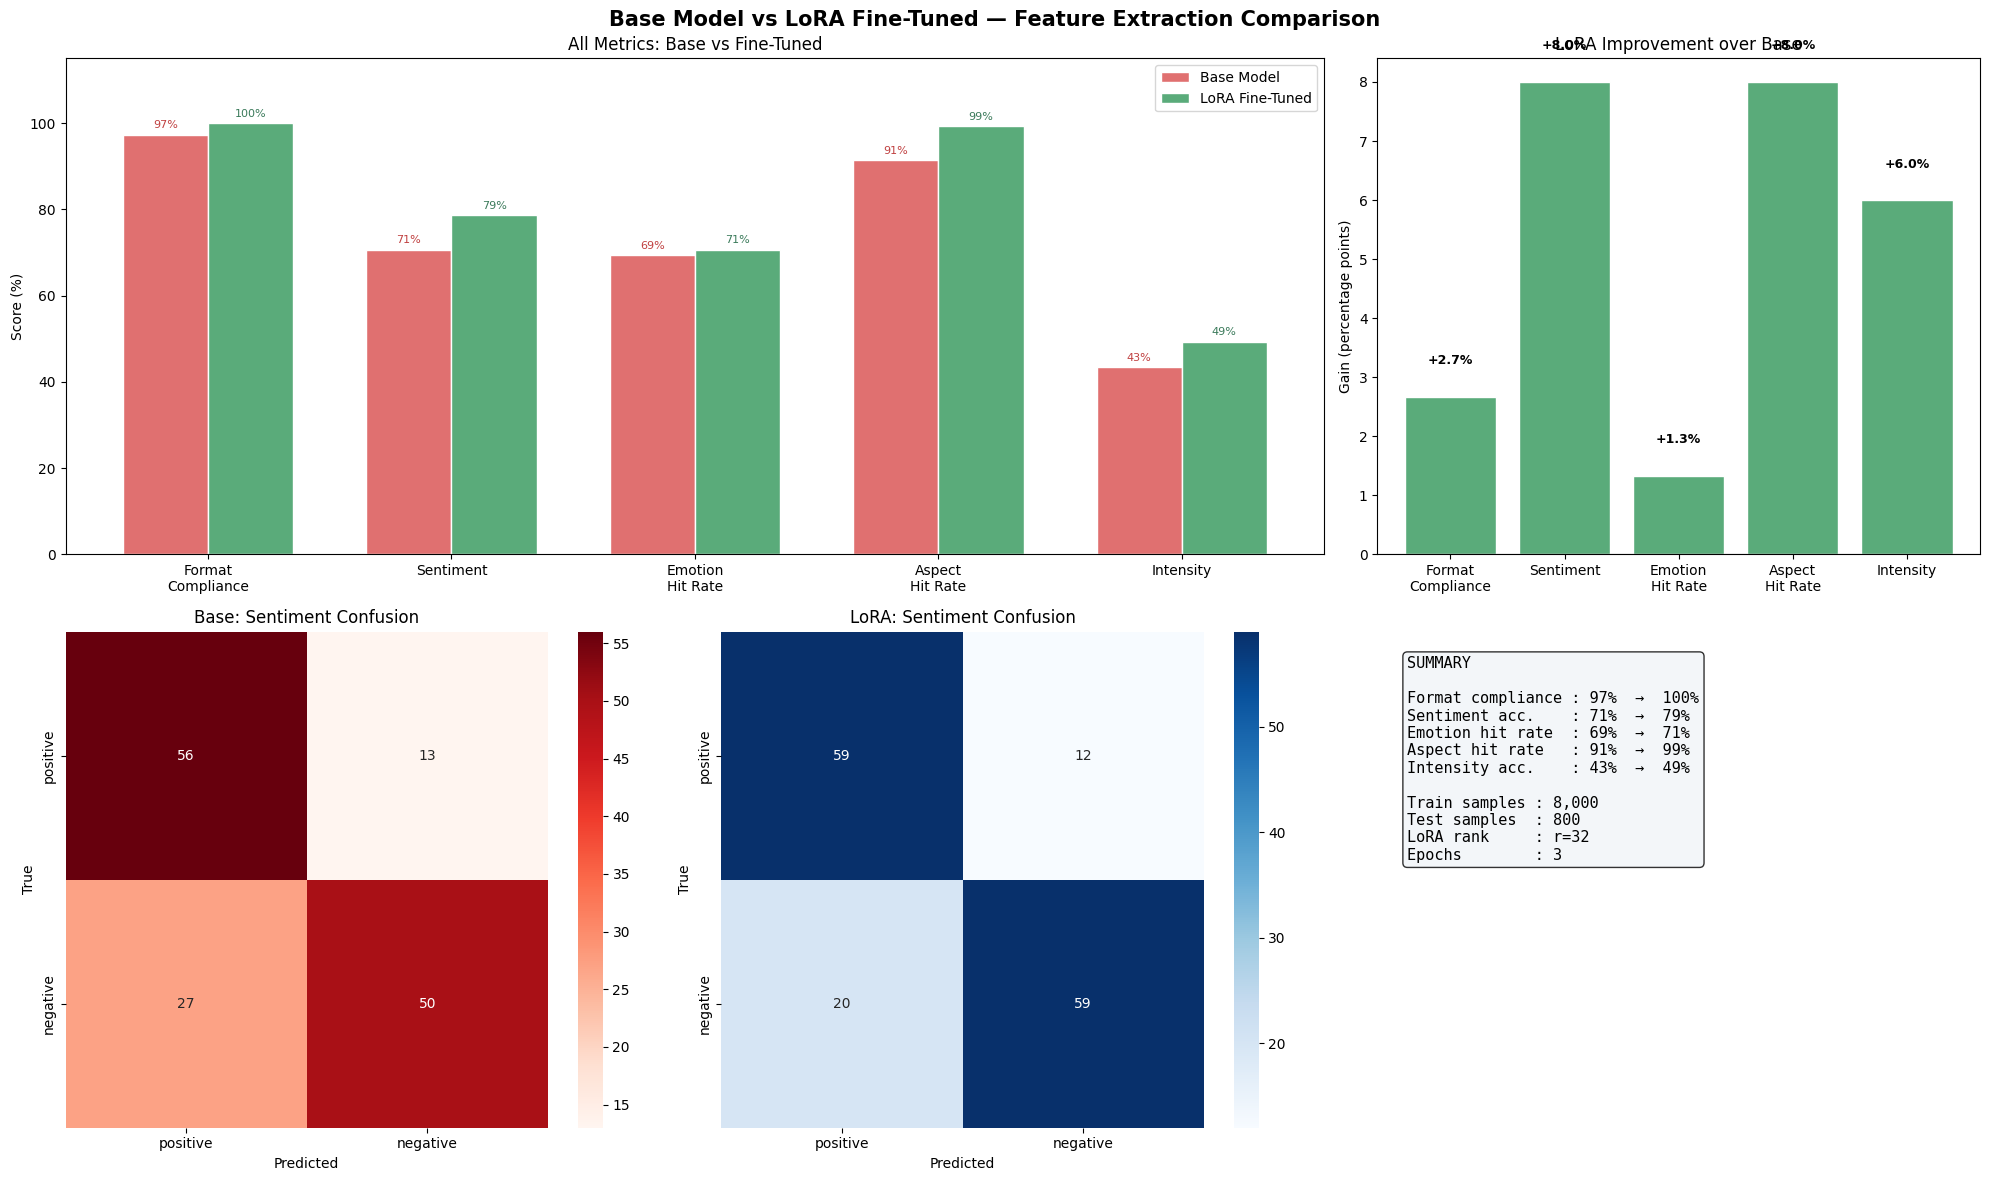

In [11]:
# ── 9b. Visual comparison ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.suptitle("Base Model vs LoRA Fine-Tuned — Feature Extraction Comparison",
             fontsize=15, fontweight='bold', y=0.98)

metrics      = ["Format\nCompliance", "Sentiment", "Emotion\nHit Rate", "Aspect\nHit Rate", "Intensity"]
base_vals    = [base_scores["fmt"], base_scores["sentiment"], base_scores["emotion"],
                base_scores["aspect"], base_scores["intensity"]]
ft_vals      = [ft_scores["fmt"],   ft_scores["sentiment"],   ft_scores["emotion"],
                ft_scores["aspect"],   ft_scores["intensity"]]

x = np.arange(len(metrics))
w = 0.35

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))
bars1 = ax1.bar(x - w/2, base_vals, w, label='Base Model',      color='#e07070', edgecolor='white')
bars2 = ax1.bar(x + w/2, ft_vals,   w, label='LoRA Fine-Tuned', color='#5aab7a', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 115)
ax1.set_ylabel('Score (%)')
ax1.set_title('All Metrics: Base vs Fine-Tuned')
ax1.legend()
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='#c04040')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='#3a7a5a')

# ── Gain chart ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 3)
gains = [ft - b for ft, b in zip(ft_vals, base_vals)]
colors_gain = ['#5aab7a' if g >= 0 else '#e07070' for g in gains]
bars_g = ax2.bar(metrics, gains, color=colors_gain, edgecolor='white')
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_ylabel('Gain (percentage points)')
ax2.set_title('LoRA Improvement over Base')
for bar, g in zip(bars_g, gains):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.5 if g >= 0 else -2),
             f'+{g:.1f}%' if g >= 0 else f'{g:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Confusion matrices ────────────────────────────────────────────────────────
labels_order = ["positive", "negative"]

ax3 = fig.add_subplot(2, 3, 4)
if base_valid_r:
    cm_b = confusion_matrix([r["true_sentiment"] for r in base_valid_r],
                             [r["pred_sentiment"] for r in base_valid_r],
                             labels=labels_order)
    sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds', ax=ax3,
                xticklabels=labels_order, yticklabels=labels_order)
ax3.set_title('Base: Sentiment Confusion')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

ax4 = fig.add_subplot(2, 3, 5)
if ft_valid_r:
    cm_f = confusion_matrix([r["true_sentiment"] for r in ft_valid_r],
                             [r["pred_sentiment"] for r in ft_valid_r],
                             labels=labels_order)
    sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=labels_order, yticklabels=labels_order)
ax4.set_title('LoRA: Sentiment Confusion')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('True')

# ── Summary box ───────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 6)
ax5.axis('off')
summary_lines = [
    "SUMMARY",
    "",
    f"Format compliance : {base_scores['fmt']:.0f}%  →  {ft_scores['fmt']:.0f}%",
    f"Sentiment acc.    : {base_scores['sentiment']:.0f}%  →  {ft_scores['sentiment']:.0f}%",
    f"Emotion hit rate  : {base_scores['emotion']:.0f}%  →  {ft_scores['emotion']:.0f}%",
    f"Aspect hit rate   : {base_scores['aspect']:.0f}%  →  {ft_scores['aspect']:.0f}%",
    f"Intensity acc.    : {base_scores['intensity']:.0f}%  →  {ft_scores['intensity']:.0f}%",
    "",
    f"Train samples : 8,000",
    f"Test samples  : 800",
    f"LoRA rank     : r=32",
    f"Epochs        : 3",
]
ax5.text(0.05, 0.95, "\n".join(summary_lines), transform=ax5.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))

plt.tight_layout()
plt.savefig('comparison_v3.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Live Demo — Both Models on Custom Reviews

In [12]:
def extract_features(model, tokenizer, review_text):
    prompt = f"""### Instruction:
Analyze the following review and extract:
1. sentiment (positive/negative)
2. emotions expressed (e.g. joy, anger, sadness, excitement, disappointment, fear, surprise)
3. aspects mentioned (e.g. acting, plot, visuals, direction, music, humor)
4. intensity (strong/moderate/weak)

Output format: sentiment: <s> | emotions: <e1>, <e2> | aspects: <a1>, <a2> | intensity: <i>

### Review:
{review_text}

### Response:
"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=600).to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=40, do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    response = tokenizer.decode(out[0], skip_special_tokens=True)
    return response.split("### Response:")[-1].strip()


test_reviews = [
    "The movie was an absolute masterpiece. The acting was brilliant and the visuals were stunning.",
    "Terrible film. Boring plot, bad acting. I walked out after 30 minutes.",
    "The battery life is terrible and dies in 3 hours, but I really love the camera quality and the screen is gorgeous.",
    "A surprisingly emotional journey. The director did a fantastic job and the soundtrack was hauntingly beautiful.",
]

for i, review in enumerate(test_reviews, 1):
    print(f"\n{'─'*70}")
    print(f"Review {i}: {review[:80]}..." if len(review) > 80 else f"Review {i}: {review}")
    print(f"{'─'*70}")
    print(f"  BASE : {extract_features(base_model, tokenizer, review)}")
    print(f"  LoRA : {extract_features(model, tokenizer, review)}")


──────────────────────────────────────────────────────────────────────
Review 1: The movie was an absolute masterpiece. The acting was brilliant and the visuals ...
──────────────────────────────────────────────────────────────────────
  BASE : sentiment: positive | emotions: joy | aspects: acting, visuals | intensity: weak
  LoRA : sentiment: positive | emotions: joy | aspects: acting, visuals | intensity: weak

──────────────────────────────────────────────────────────────────────
Review 2: Terrible film. Boring plot, bad acting. I walked out after 30 minutes.
──────────────────────────────────────────────────────────────────────
  BASE : sentiment: negative | emotions: disappointment | aspects: acting, plot | intensity: weak
  LoRA : sentiment: negative | emotions: disappointment | aspects: acting, plot | intensity: weak

──────────────────────────────────────────────────────────────────────
Review 3: The battery life is terrible and dies in 3 hours, but I really love the camera q.